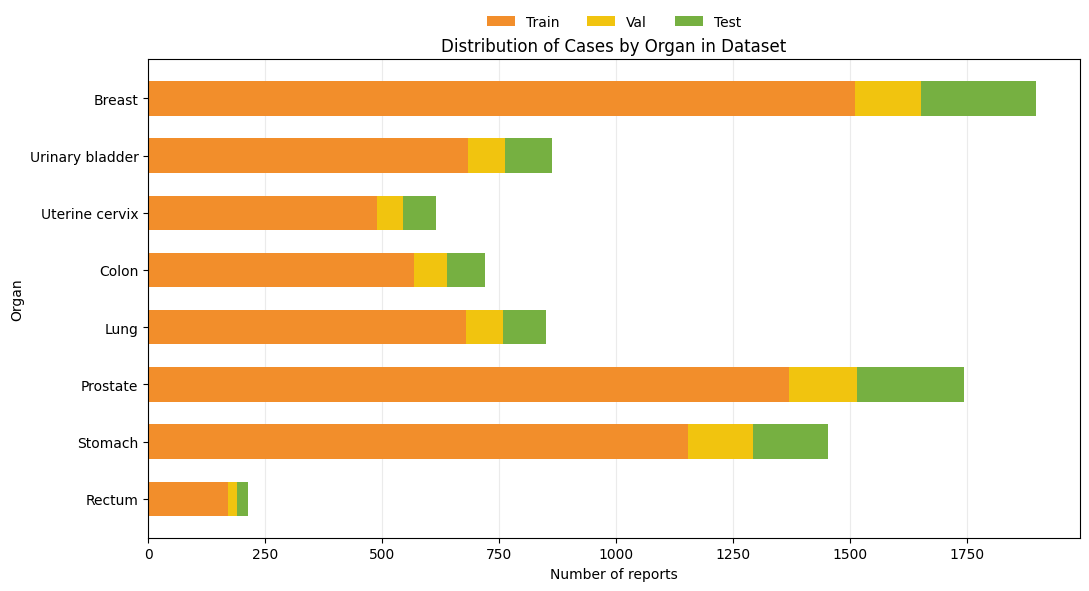


Summed report counts by organ and split:
split            train  val  test  Total
Organ                                   
Breast            1510  141   245   1896
Urinary bladder    684   78   101    863
Uterine cervix     489   55    70    614
Colon              568   70    82    720
Lung               678   80    93    851
Prostate          1370  145   227   1742
Stomach           1154  139   160   1453
Rectum             170   19    24    213


In [ ]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

csv_path = "organ_report_lengths_by_split.csv"
df = pd.read_csv(csv_path)

mapping = {
    "Cervix": "Uterine cervix",
    "Anus": "Rectum",
    "Nipple": "Breast",
    "Invasive micropapillary carcinoma": "Breast",
    "stomach": "Stomach",
    "Bladder": "Urinary bladder",
}

df["Organ"] = df["Organ"].replace(mapping)

order = [
    "Breast",
    "Urinary bladder",
    "Uterine cervix",
    "Colon",
    "Lung",
    "Prostate",
    "Stomach",
    "Rectum",
]

pivot = (
    df.groupby(["Organ", "split"], as_index=False)["n_reports"]
    .sum()
    .pivot(index="Organ", columns="split", values="n_reports")
    .reindex(order)
    .fillna(0)
    .astype(int)
)

# Add total column
pivot["Total"] = pivot[["train", "val", "test"]].sum(axis=1)

# Optional: reorder columns for cleaner printing
pivot = pivot[["train", "val", "test", "Total"]]

# Better PDF font embedding
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

fig, ax = plt.subplots(figsize=(11, 6))

colors = {
    "train": "#F28E2B",
    "val": "#F1C40F",
    "test": "#76B041",
}

left = pd.Series(0, index=pivot.index)

for split in ["train", "val", "test"]:
    ax.barh(
        pivot.index,
        pivot[split],
        left=left,
        label=split.capitalize(),
        color=colors[split],
        height=0.6,
    )
    left = left + pivot[split]

ax.invert_yaxis()
#ax.set_xlabel("Number of reports")
#ax.set_ylabel("Organ")
#ax.set_title("Distribution of Cases by Organ in Dataset")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.12), frameon=False)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()

# Save high-quality outputs
fig.savefig("organ_split_bar.png", dpi=300, bbox_inches="tight")
fig.savefig("organ_split_bar.pdf", format="pdf", bbox_inches="tight")

plt.show()

print("\nSummed report counts by organ and split:")
print(pivot)

In [2]:
# Print how many unique organs are present in each split
organs_per_split = df.groupby("split")["Organ"].nunique()
print("Number of organs per split:")
print(organs_per_split)

Number of organs per split:
split
test     8
train    8
val      8
Name: Organ, dtype: int64
